#### Dataset Information

The dataset contains cases from a study that was conducted between 1958 and 1970 at the University of Chicago's Billings Hospital on the survival of patients who had undergone surgery for breast cancer.

#### Objective

To predict whether patient will survive for 5 years or more after operation. 

In [208]:
#importing all the necessary modules and loading the dataset

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

cancer = pd.read_csv("haberman.csv")
cancer["Surv_status"].replace({1:"Yes",2:"No"}, value=None, inplace=True)


In [45]:
cancer.head()

,Age,Op_Year,axil_nodes,Surv_status
0,30,64,1,Yes
1,30,62,3,Yes
2,30,65,0,Yes
3,31,59,2,Yes
4,31,65,4,Yes


In [296]:
# number of data points and features

print(cancer.shape)

(306, 4)


There are 3 variables, 1 class and 306 datapoints in our dataset

In [47]:
# name of the coloums

print(cancer.columns)

Index(['Age', 'Op_Year', 'axil_nodes', 'Surv_status'], dtype='object')


There are 4 Variable in this dataset
1. Age of patient : Age
2. Patient year of operation : Op_Year
3. Number of positive axillary nodes detected : axil_nodes
4. Survival status (class attribute) : Surv_status
    (1 = the patient survived 5 years or longer, 
    2 = the patient died within 5 year)

In [212]:
# number of data points for each class 

cancer["Surv_status"].value_counts()

Yes    225
No      81
Name: Surv_status, dtype: int64

1. 281 patients survived 5 years or more after operation.
2. 81 patient died within 5 years of operation.
3. This is a partially imbalanced dataset.

In [79]:
cancer.describe()

,Age,Op_Year,axil_nodes
count,306.000000,306.000000,306.000000
mean,52.457516,62.852941,4.026144
std,10.803452,3.249405,7.189654
min,30.000000,58.000000,0.000000
25%,44.000000,60.000000,0.000000
50%,52.000000,63.000000,1.000000
75%,60.750000,65.750000,4.000000
max,83.000000,69.000000,52.000000


#### Observation

1. Minimun age of Patient is 30 years and maximum age is 83 years. Whereas average patient age is 52 years.
2. 25% patient were below 44 years and 75% of the patients were below 61 years. Only 25% patients were between 61 years to 83 years.
3. All the operations took place between 1958 to 1969
4. 25% of patients have 0 positive axillary nodes, 50% had 1 or less positive axillary nodes and 75% had 4 or less positive axillary nodes.
5. Only 25% patients had more than 4 positive axillary nodes.


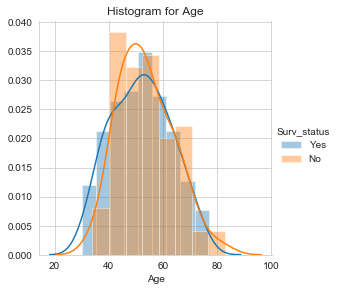

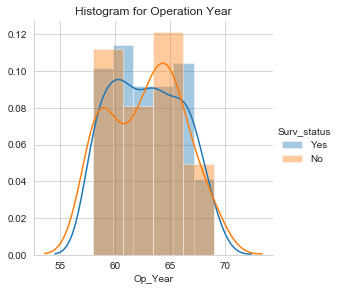

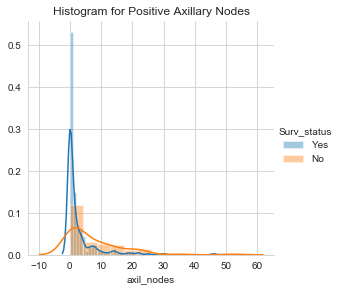

In [299]:
# Histogram plot
plt.close()

sns.FacetGrid(cancer, hue='Surv_status', height = 4)\
   .map(sns.distplot,'Age', ).add_legend()
plt.title("Histogram for Age")

sns.FacetGrid(cancer, hue='Surv_status', height = 4)\
   .map(sns.distplot,'Op_Year')\
   .add_legend()
plt.title("Histogram for Operation Year")

sns.FacetGrid(cancer, hue='Surv_status', height = 4)\
   .map(sns.distplot,'axil_nodes')\
   .add_legend()
plt.title("Histogram for Positive Axillary Nodes")
plt.show()

#### Observations

1. Patients who have 2 or less positive axillary nodes have high chances of survival after 5 years.

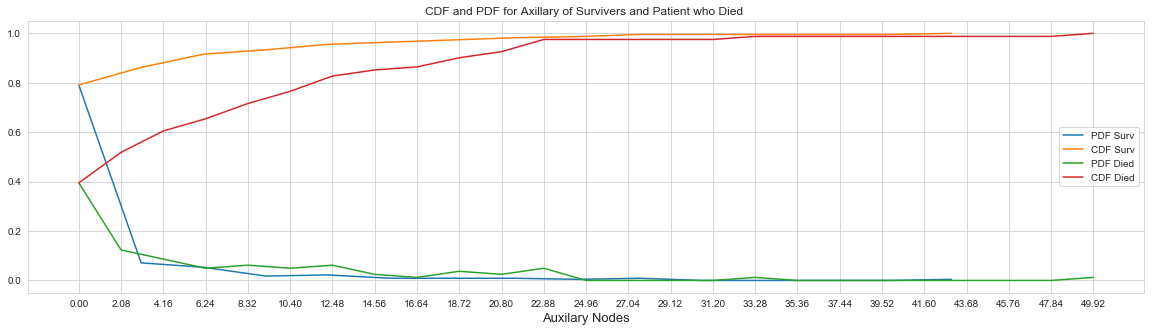

In [300]:
# pdf and cdf for Axillary nodes of Survived Patients
cancer_sur = cancer[cancer["Surv_status"]=='Yes']
plt.figure(figsize=(20,5))
counts, bin_edges = np.histogram(cancer_sur["axil_nodes"], bins=15, density=True)
pdf = counts/sum(counts)
cdf = np.cumsum(pdf)
plt.plot(bin_edges[:-1],pdf)
plt.plot(bin_edges[:-1], cdf)
plt.xticks(bin_edges[:-1])
plt.xlabel("Auxilary Nodes", fontsize = 13)

# pdf and cdf for Axillary nodes of Patients who dies
cancer_d = cancer[cancer["Surv_status"]=='No']
counts, bin_edges = np.histogram(cancer_d["axil_nodes"], bins=25, density=True)
pdf = counts/sum(counts)
cdf = np.cumsum(pdf)
plt.plot(bin_edges[:-1],pdf)
plt.plot(bin_edges[:-1], cdf)
plt.xticks(bin_edges[:-1])
plt.xlabel("Auxilary Nodes", fontsize = 13)
plt.legend(['PDF Surv', 'CDF Surv', 'PDF Died', 'CDF Died'])
plt.title("CDF and PDF of Axillary nodes for Survivers and Patient who Died ")

plt.show()

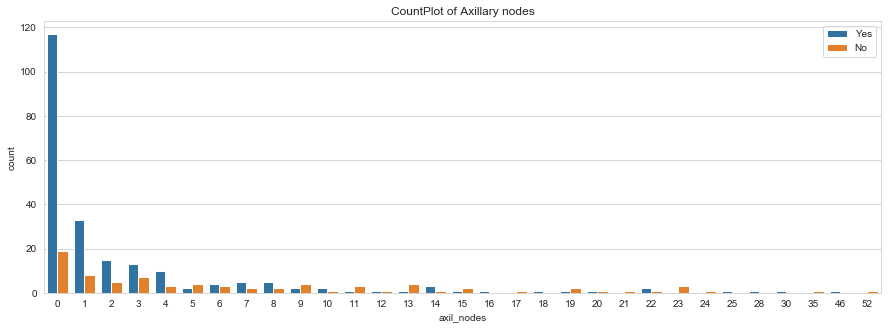

In [301]:
# countplot of Axillary nodes

plt.figure(figsize=(15,5))
sns.countplot(x='axil_nodes', data=cancer ,hue='Surv_status')
plt.legend(loc='upper right')
plt.title("CountPlot of Axillary nodes")
plt.show()


#### Observation
1. Approximately 85% of patient survived who had less than 2 positive axillary nodes


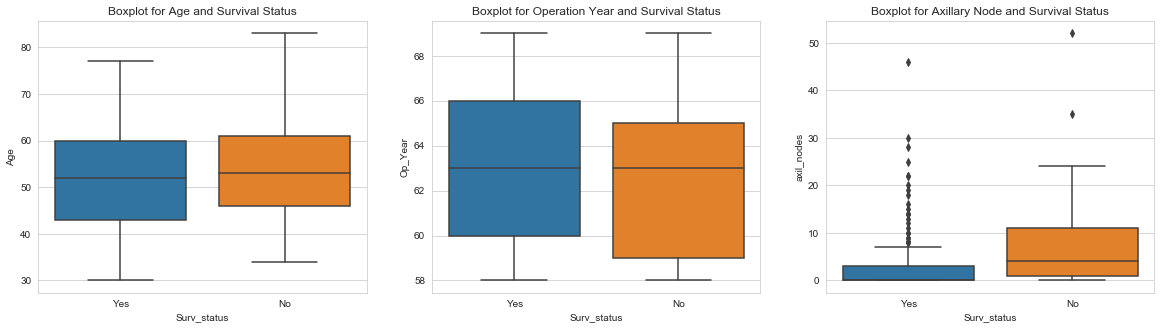

In [303]:
# box plot

plt.figure(figsize=(20,5))

plt.subplot(131)
sns.boxplot(x="Surv_status", y="Age", data=cancer)
plt.title("Boxplot for Age and Survival Status")

plt.subplot(132)
sns.boxplot(x="Surv_status", y="Op_Year", data=cancer)
plt.title("Boxplot for Operation Year and Survival Status")

plt.subplot(133)
sns.boxplot(x="Surv_status", y="axil_nodes", data=cancer)
plt.title("Boxplot for Axillary Node and Survival Status")
plt.show()

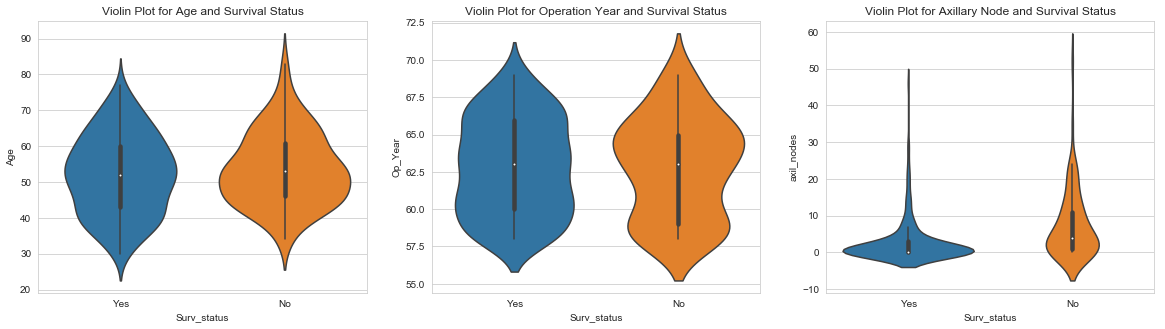

In [304]:
# Violin plot

plt.figure(figsize=(20,5))
plt.subplot(131)
sns.violinplot(x='Surv_status', y="Age", data=cancer)
plt.title("Violin Plot for Age and Survival Status")


plt.subplot(132)
sns.violinplot(x='Surv_status', y="Op_Year", data=cancer)
plt.title("Violin Plot for Operation Year and Survival Status")

plt.subplot(133)
sns.violinplot(x='Surv_status', y="axil_nodes", data=cancer)
plt.title("Violin Plot for Axillary Node and Survival Status")
plt.show()


#### Observations

1. Patients which are operated after 1965 had less death rate.
2. 75% of Patients who survived had 3 or less positive axillary nodes.
3. Only 25% of patients who died had 1 or less positive axillary nodes.
3. 75% of Survivers are 60 years old or younger.

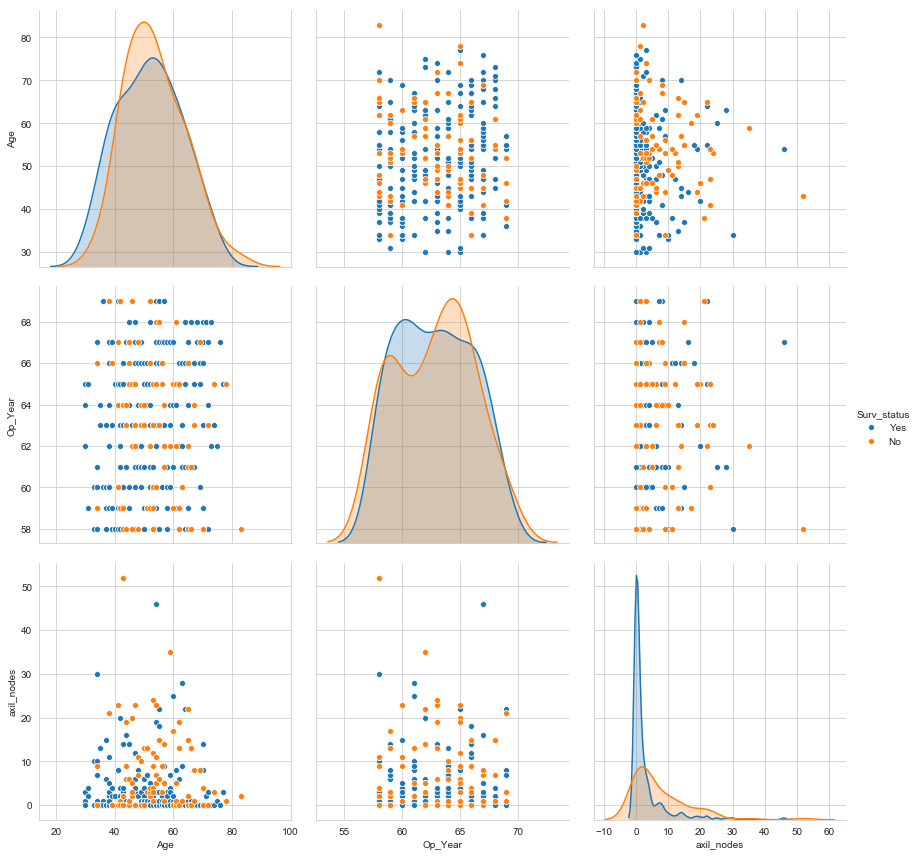

In [292]:
# pairwise scatter plot: Pair-Plot
plt.close()
sns.set_style('whitegrid')
sns.pairplot(cancer, hue="Surv_status", height = 4)
plt.show()


#### Observation

As data is overlapping in all three upper diagonal graphs therefore it is very difficult to make any conclusion out of it.




### To Sum Up

Our Major Observations were:
1. Approximately 85% of patient survived who had less than 2 positive axillary nodes.
2. Only 25% of patients who died had 1 or less positive axillary nodes.

Patients who have positive axillary nodes less than 2 have higher chances of survival.